In [1]:
import tensorflow as tf
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

In [18]:
def load_data():
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    return df

def preprocess_data(df):
    df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
    
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    
    df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
    
    X = df.drop(columns=['Survived'])
    y = df['Survived']
    
    scaler = StandardScaler()
    X[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']] = scaler.fit_transform(X[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    return X_train, X_test, y_train, y_test

In [3]:
df = load_data()
X_train, X_test, y_train, y_test = preprocess_data(df)

C:\Users\vaibh\AppData\Local\Temp\ipykernel_12120\1965702790.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\vaibh\AppData\Local\Temp\ipykernel_12120\1965702790.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [12]:
def build_model(input_shape, optimizer):
    model = Sequential([
        tf.keras.layers.Input(shape=(input_shape,)), 
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
])
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [13]:
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001)
}

lr_schedules = {
    "Step Decay": tf.keras.optimizers.schedules.PiecewiseConstantDecay([10, 30], [0.01, 0.005, 0.001]),
    "Exponential Decay": tf.keras.optimizers.schedules.ExponentialDecay(0.01, decay_steps=10000, decay_rate=0.96, staircase=True),
    "Piecewise Constant Decay": tf.keras.optimizers.schedules.PiecewiseConstantDecay([10, 30], [0.01, 0.005, 0.001]),
    "Cosine Decay": tf.keras.optimizers.schedules.CosineDecay(0.01, decay_steps=10000)
}

In [16]:
results = {}
for opt_name, opt in optimizers.items():
    for sched_name, sched in lr_schedules.items():
        optimizer = type(opt)(learning_rate=sched)
        model = build_model(X_train.shape[1], optimizer)
        history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)
        results[(opt_name, sched_name)] = history.history

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5675 - loss: 26.4125 - val_accuracy: 0.5866 - val_loss: 0.6917
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6433 - loss: 0.6891 - val_accuracy: 0.5866 - val_loss: 0.6910
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6188 - loss: 0.6887 - val_accuracy: 0.5866 - val_loss: 0.6907
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6192 - loss: 0.6890 - val_accuracy: 0.5866 - val_loss: 0.6904
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6210 - loss: 0.6885 - val_accuracy: 0.5866 - val_loss: 0.6902
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6083 - loss: 0.6885 - val_accuracy: 0.5866 - val_loss: 0.6899
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6400 - loss: 0.6848 - val_accuracy: 0.5866 - val_loss: 0.6897
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6313 - loss: 0.6863 - val_accuracy: 0.5866 - val_loss

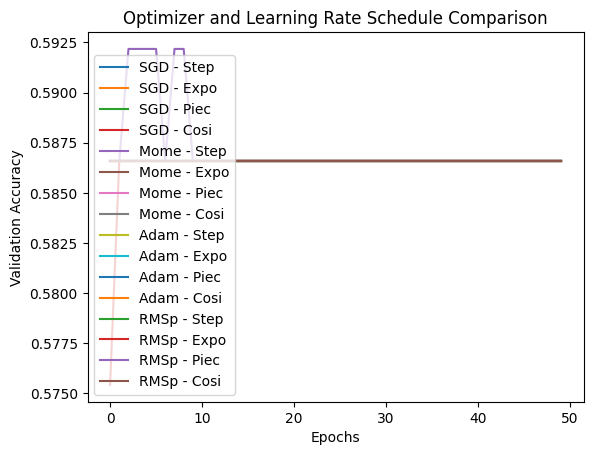

In [17]:
for (opt_name, sched_name), history in results.items():
    plt.plot(history['val_accuracy'], label=f'{opt_name[:4]} - {sched_name[:4]}')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Optimizer and Learning Rate Schedule Comparison')
plt.show()